# <font color= #003366> **Análisis de Sentimiento** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 2: </Strong>  <font color="blue">`GANs` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

## <font color=  #003366> **Introducción**</font>

En este notebook se presenta la sección de visualización del proyecto de análisis de reseñas de Amazon. Su objetivo es complementar el desarrollo del sistema de clasificación de sentimientos mediante una representación gráfica clara de los datos utilizados y de los resultados obtenidos.

Estas visualizaciones permiten analizar de forma más intuitiva el comportamiento del dataset, identificar patrones generales en las reseñas y apoyar la interpretación del desempeño del modelo. De esta manera, el notebook funciona como una herramienta de análisis que facilita la comprensión del proyecto y fortalece las conclusiones finales.

In [12]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [2]:
dataset = load_dataset("amazon_polarity")

df_train = dataset['train'].shuffle(seed=42).select(range(10000))
df_test = dataset['test'].shuffle(seed=42).select(range(2000))

df_train = df_train.rename_column("label", "labels")
df_test = df_test.rename_column("label", "labels")

split = df_train.train_test_split(test_size=0.2, seed=42)

df_train = split["train"]
df_val = split["test"]

def combinar(example):
    return {
        "text": example["title"] + " " + example["content"]
    }

df_train = df_train.map(combinar)
df_test = df_test.map(combinar)
df_val = df_val.map(combinar)

df_train = df_train.remove_columns(["title", "content"])
df_test = df_test.remove_columns(["title", "content"])
df_val = df_val.remove_columns(["title", "content"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [14]:
train_viz = df_train.to_pandas()
val_viz = df_val.to_pandas()
test_viz = df_test.to_pandas()

label_map = {
    0: "Negativo",
    1: "Positivo"
}

train_viz["sentimiento"] = train_viz["labels"].map(label_map)
val_viz["sentimiento"] = val_viz["labels"].map(label_map)
test_viz["sentimiento"] = test_viz["labels"].map(label_map)

train_viz["num_chars"] = train_viz["text"].str.len()
val_viz["num_chars"] = val_viz["text"].str.len()
test_viz["num_chars"] = test_viz["text"].str.len()

train_viz["num_words"] = train_viz["text"].str.split().str.len()
val_viz["num_words"] = val_viz["text"].str.split().str.len()
test_viz["num_words"] = test_viz["text"].str.split().str.len()

display(train_viz.head())

,labels,text,sentimiento,num_chars,num_words
0,1,great music The music was great and I absolute...,Positivo,182,32
1,1,Love it! I get a lot of compliments on this ha...,Positivo,139,28
2,0,Very Little That's New Not a bad read if you'r...,Negativo,421,73
3,1,A great tool My husband and I have used our bl...,Positivo,295,57
4,0,Don't Bother! If you're looking to fish in the...,Negativo,264,47


,Train,Validation,Test
sentimiento,,,
Negativo,3995,1008,982
Positivo,4005,992,1018


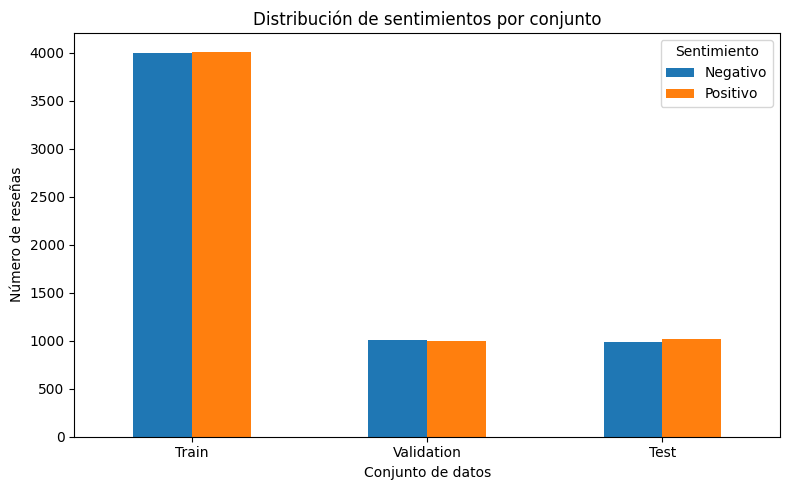

In [4]:
class_counts = pd.DataFrame({
    "Train": train_viz["sentimiento"].value_counts(),
    "Validation": val_viz["sentimiento"].value_counts(),
    "Test": test_viz["sentimiento"].value_counts()
}).fillna(0).astype(int)

display(class_counts)

class_counts.T.plot(kind="bar", figsize=(8, 5))

plt.title("Distribución de sentimientos por conjunto")
plt.xlabel("Conjunto de datos")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()

La gráfica muestra que las reseñas positivas y negativas están equilibradas en los conjuntos de entrenamiento, validación y prueba. Esto es importante porque permite que el modelo aprenda ambas clases de manera similar, sin favorecer una categoría sobre la otra.

,Train,Validation,Test
count,8000.00,2000.00,2000.00
mean,78.22,77.85,77.55
std,42.51,42.45,42.38
min,15.00,17.00,15.00
25%,42.00,43.00,42.00
50%,70.00,70.00,69.00
75%,108.00,107.00,107.00
max,212.00,209.00,196.00


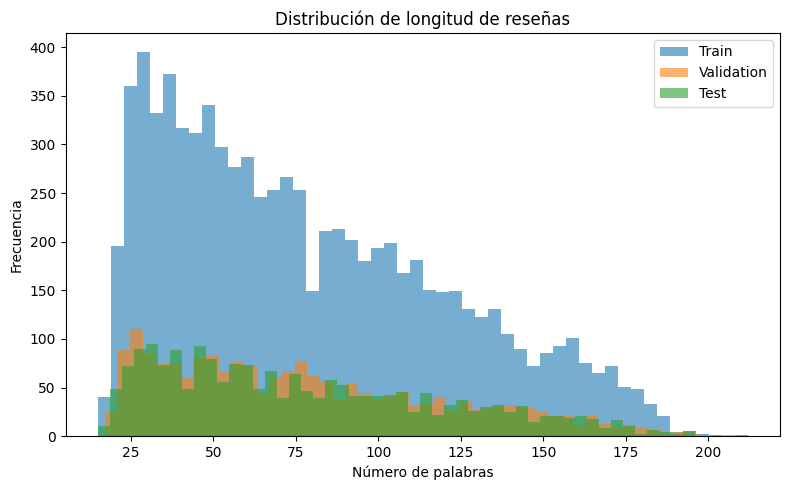

In [6]:
length_summary = pd.DataFrame({
    "Train": train_viz["num_words"].describe(),
    "Validation": val_viz["num_words"].describe(),
    "Test": test_viz["num_words"].describe()
})

display(length_summary.round(2))

plt.figure(figsize=(8, 5))

plt.hist(train_viz["num_words"], bins=50, alpha=0.6, label="Train")
plt.hist(val_viz["num_words"], bins=50, alpha=0.6, label="Validation")
plt.hist(test_viz["num_words"], bins=50, alpha=0.6, label="Test")

plt.title("Distribución de longitud de reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

La gráfica muestra que la mayoría de las reseñas tienen una longitud media, alrededor de 70 a 80 palabras, y que los tres conjuntos mantienen una distribución parecida. Esto es útil porque confirma que entrenamiento, validación y prueba tienen textos con características similares, lo que ayuda a evaluar el modelo de forma más confiable.

,num_words,num_chars
sentimiento,,
Negativo,81.33,446.03
Positivo,75.12,412.75


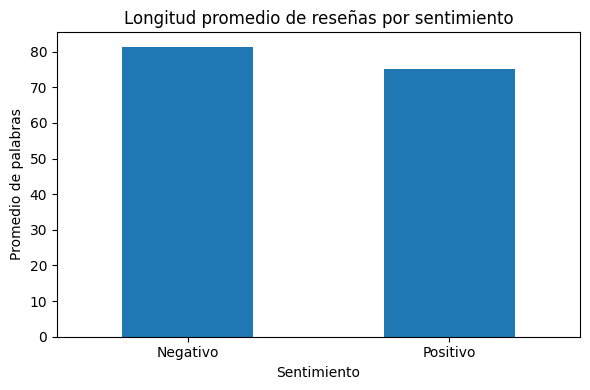

In [7]:
avg_length = train_viz.groupby("sentimiento")[["num_words", "num_chars"]].mean()

display(avg_length.round(2))

avg_length["num_words"].plot(kind="bar", figsize=(6, 4))

plt.title("Longitud promedio de reseñas por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Promedio de palabras")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La gráfica muestra que las reseñas negativas son ligeramente más largas que las positivas, tanto en número de palabras como de caracteres. Esto puede indicar que los usuarios tienden a explicar más cuando tienen una mala experiencia, lo cual ayuda a entender mejor el comportamiento del texto según el sentimiento.

<Figure size 800x500 with 0 Axes>

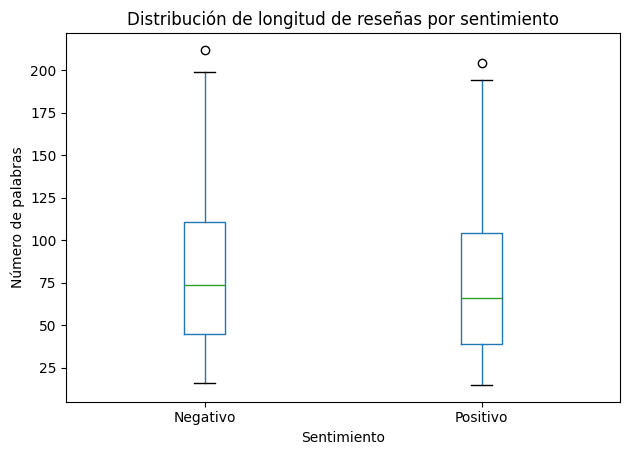

In [11]:
plt.figure(figsize=(8, 5))

train_viz.boxplot(
    column="num_words",
    by="sentimiento",
    grid=False
)

plt.title("Distribución de longitud de reseñas por sentimiento")
plt.suptitle("")
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras")
plt.tight_layout()
plt.show()

El boxplot muestra que las reseñas negativas suelen tener una mediana un poco más alta y una mayor dispersión en la cantidad de palabras. Esto refuerza la idea de que las reseñas negativas tienden a ser más extensas, posiblemente porque los usuarios explican con más detalle sus problemas o inconformidades.

,palabra,frecuencia
0,book,2022
1,one,1541
2,like,1257
3,very,1113
4,good,974
5,get,900
6,only,856
7,don,841
8,your,798
9,more,795


,palabra,frecuencia
0,book,2276
1,great,1839
2,one,1451
3,good,1335
4,very,1284
5,like,1078
6,read,928
7,love,831
8,more,783
9,well,731


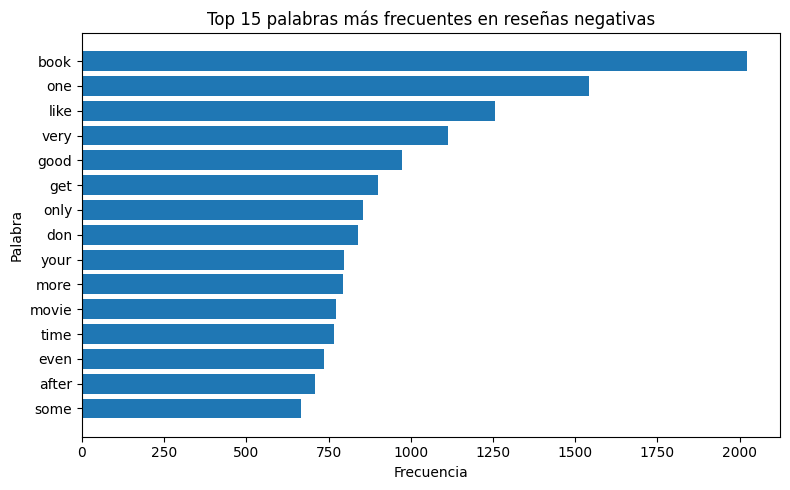

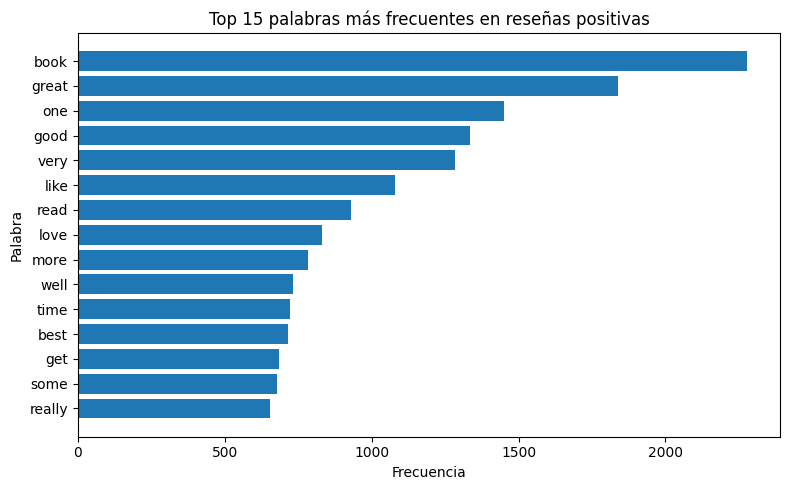

In [13]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    palabras = texto.split()

    stopwords = {
        "the", "and", "a", "an", "to", "of", "is", "it", "this", "that",
        "in", "for", "on", "with", "was", "were", "as", "at", "by",
        "be", "are", "or", "from", "but", "not", "you", "i", "my",
        "they", "we", "he", "she", "his", "her", "their", "our",
        "so", "if", "out", "about", "what", "which", "when", "who",
        "there", "here", "all", "just", "can", "will", "would", "could",
        "should", "have", "has", "had", "do", "does", "did"
    }

    palabras = [
        palabra for palabra in palabras
        if palabra not in stopwords and len(palabra) > 2
    ]

    return palabras

def top_palabras_por_sentimiento(df, sentimiento, n=15):
    textos = df[df["sentimiento"] == sentimiento]["text"]
    todas_palabras = []

    for texto in textos:
        todas_palabras.extend(limpiar_texto(texto))

    conteo = Counter(todas_palabras)
    return pd.DataFrame(
        conteo.most_common(n),
        columns=["palabra", "frecuencia"]
    )

top_negativas = top_palabras_por_sentimiento(train_viz, "Negativo", n=15)
top_positivas = top_palabras_por_sentimiento(train_viz, "Positivo", n=15)

display(top_negativas)
display(top_positivas)

plt.figure(figsize=(8, 5))
plt.barh(top_negativas["palabra"], top_negativas["frecuencia"])
plt.title("Top 15 palabras más frecuentes en reseñas negativas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(top_positivas["palabra"], top_positivas["frecuencia"])
plt.title("Top 15 palabras más frecuentes en reseñas positivas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La gráfica muestra las palabras más frecuentes en reseñas negativas y positivas. Se observa que algunas palabras aparecen en ambos grupos, pero en las positivas destacan términos como “great”, “best” y “well”, mientras que en las negativas aparecen más palabras asociadas a experiencias menos favorables. Esto es útil porque permite identificar patrones de lenguaje relacionados con cada sentimiento.